In [2]:
import os
from dotenv import load_dotenv

In [3]:
load_dotenv()

OPEN_ROUTER_API_KEY = os.getenv("OPEN_ROUTER_API_KEY")

In [4]:
import json
from typing import Any, Optional

import requests
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.outputs import ChatGeneration, ChatResult
from langchain_core.utils.function_calling import convert_to_openai_tool
from pydantic import Field


class ChatOpenRouter(BaseChatModel):
    """Thin wrapper around OpenRouter that preserves the `reasoning` field."""

    model: str
    api_key: str
    base_url: str = "https://openrouter.ai/api/v1/chat/completions"
    include_reasoning: bool = True
    temperature: Optional[float] = None
    max_tokens: Optional[int] = None
    extra_params: dict = Field(default_factory=dict)

    @property
    def _llm_type(self) -> str:
        return "openrouter"

    @staticmethod
    def _format_messages(messages: list[BaseMessage]) -> list[dict]:
        result = []
        for msg in messages:
            if isinstance(msg, SystemMessage):
                result.append({"role": "system", "content": msg.content})
            elif isinstance(msg, HumanMessage):
                result.append({"role": "user", "content": msg.content})
            elif isinstance(msg, AIMessage):
                entry: dict[str, Any] = {"role": "assistant"}
                entry["content"] = msg.content or ""
                reasoning = msg.additional_kwargs.get("reasoning")
                if reasoning:
                    entry["reasoning"] = reasoning
                if msg.tool_calls:
                    entry["tool_calls"] = [
                        {
                            "id": tc["id"],
                            "type": "function",
                            "function": {
                                "name": tc["name"],
                                "arguments": json.dumps(tc["args"]),
                            },
                        }
                        for tc in msg.tool_calls
                    ]
                result.append(entry)
            elif isinstance(msg, ToolMessage):
                result.append(
                    {
                        "role": "tool",
                        "content": msg.content,
                        "tool_call_id": msg.tool_call_id,
                    }
                )
        return result

    def _generate(
        self,
        messages: list[BaseMessage],
        stop: Optional[list[str]] = None,
        run_manager: Any = None,
        **kwargs: Any,
    ) -> ChatResult:
        payload: dict[str, Any] = {
            "model": self.model,
            "messages": self._format_messages(messages),
            "include_reasoning": self.include_reasoning,
            **self.extra_params,
        }
        if stop:
            payload["stop"] = stop
        if self.temperature is not None:
            payload["temperature"] = self.temperature
        if self.max_tokens is not None:
            payload["max_tokens"] = self.max_tokens
        if "tools" in kwargs:
            payload["tools"] = kwargs["tools"]

        resp = requests.post(
            self.base_url,
            headers={
                "Authorization": f"Bearer {self.api_key}",
                "Content-Type": "application/json",
            },
            json=payload,
            timeout=300,
        )
        resp.raise_for_status()
        data = resp.json()

        choice = data["choices"][0]
        raw_msg = choice["message"]

        additional_kwargs: dict[str, Any] = {}
        if raw_msg.get("reasoning"):
            additional_kwargs["reasoning"] = raw_msg["reasoning"]

        tool_calls = []
        if raw_msg.get("tool_calls"):
            for tc in raw_msg["tool_calls"]:
                args = tc["function"]["arguments"]
                tool_calls.append(
                    {
                        "id": tc["id"],
                        "name": tc["function"]["name"],
                        "args": json.loads(args) if isinstance(args, str) else args,
                    }
                )

        ai_msg = AIMessage(
            content=raw_msg.get("content") or "",
            additional_kwargs=additional_kwargs,
            tool_calls=tool_calls,
        )
        return ChatResult(generations=[ChatGeneration(message=ai_msg)])

    def bind_tools(self, tools: list, **kwargs: Any):
        formatted = [convert_to_openai_tool(t) for t in tools]
        return self.bind(tools=formatted, **kwargs)


def get_reasoning(msg: AIMessage) -> str | None:
    """Extract reasoning tokens from an OpenRouter response."""
    return msg.additional_kwargs.get("reasoning")


def print_messages(messages: list[BaseMessage]) -> None:
    """Pretty-print a message list, including reasoning for AI messages."""
    for msg in messages:
        if isinstance(msg, HumanMessage):
            print(f"{'=' * 32} Human Message {'=' * 33}\n")
            print(msg.content)
        elif isinstance(msg, AIMessage):
            print(f"{'=' * 34} Ai Message {'=' * 34}\n")
            reasoning = get_reasoning(msg)
            if reasoning:
                print(f"[Reasoning]\n{reasoning}\n")
            if msg.tool_calls:
                print("Tool Calls:")
                for tc in msg.tool_calls:
                    print(f"  {tc['name']} ({tc['id']})")
                    print(f"  Args:")
                    for k, v in tc["args"].items():
                        print(f"    {k}: {v}")
            if msg.content:
                print(msg.content)
        elif isinstance(msg, ToolMessage):
            print(f"{'=' * 33} Tool Message {'=' * 33}\n")
            print(msg.content)
        print()

In [5]:
import json
import sqlite3
from langchain.tools import tool

TRAIN_DB_PATH = "/Users/kulyaskin_mikhail/ITMO/Agents/Text2SQL/data/train/train_databases"
DEV_DB_PATH = "/Users/kulyaskin_mikhail/ITMO/Agents/Text2SQL/data/dev_20240627/dev_databases"

TRAIN_TABLES_PATH = "/Users/kulyaskin_mikhail/ITMO/Agents/Text2SQL/data/train/train_tables.json"
DEV_TABLES_PATH = "/Users/kulyaskin_mikhail/ITMO/Agents/Text2SQL/data/dev_20240627/dev_tables.json"

with open(DEV_TABLES_PATH, "r", encoding="utf-8") as _f:
    _raw = json.load(_f)
DB_SCHEMAS = {entry["db_id"]: entry for entry in _raw}
del _raw, _f


def _get_pk_fk_info(db_name: str, table_name: str) -> str:
    schema = DB_SCHEMAS.get(db_name)
    if not schema:
        return ""

    table_names = schema["table_names_original"]
    try:
        table_idx = next(
            i for i, t in enumerate(table_names) if t.lower() == table_name.lower()
        )
    except StopIteration:
        return ""

    columns = schema["column_names_original"]
    col_indices = {
        i for i, (tbl_idx, _) in enumerate(columns) if tbl_idx == table_idx
    }

    def _col_label(idx: int) -> str:
        tbl_idx, col_name = columns[idx]
        return f"{table_names[tbl_idx]}.{col_name}" if tbl_idx >= 0 else col_name

    parts = []

    pk_cols = []
    for pk in schema.get("primary_keys", []):
        indices = pk if isinstance(pk, list) else [pk]
        if any(i in col_indices for i in indices):
            pk_cols.append([columns[i][1] for i in indices])
    if pk_cols:
        parts.append("Primary keys:")
        for group in pk_cols:
            parts.append(f"  - ({', '.join(group)})" if len(group) > 1 else f"  - {group[0]}")

    fk_out = [
        (fr, to) for fr, to in schema.get("foreign_keys", []) if fr in col_indices
    ]
    fk_in = [
        (fr, to) for fr, to in schema.get("foreign_keys", []) if to in col_indices
    ]
    if fk_out:
        parts.append("Foreign keys (outgoing):")
        for fr, to in fk_out:
            parts.append(f"  - {columns[fr][1]} -> {_col_label(to)}")
    if fk_in:
        parts.append("Foreign keys (incoming):")
        for fr, to in fk_in:
            parts.append(f"  - {_col_label(fr)} -> {columns[to][1]}")

    return "\n".join(parts)


@tool
def get_db_overview(db_name: str) -> str:
    """List all tables in a database and read its documentation, if available.

    Args:
        db_name: Name of the database directory (e.g. 'app_store').

    Returns:
        SQLite table names followed by the contents of documentation.md with
        domain-specific notes, definitions and constraints, or a note if no
        documentation file exists.
    """
    db_dir = os.path.join(DEV_DB_PATH, db_name)
    sqlite_file = os.path.join(db_dir, f"{db_name}.sqlite")

    conn = sqlite3.connect(sqlite_file)
    cursor = conn.execute(
        "SELECT name FROM sqlite_master WHERE type='table' AND name != 'sqlite_sequence'"
    )
    tables = sorted(r[0] for r in cursor.fetchall())
    conn.close()

    lines = [f"Database: {db_name}", "", "SQLite tables:"]
    lines.extend(f"  - {t}" for t in tables)

    doc_path = os.path.join(
        DEV_DB_PATH, db_name, "database_description", "documentation.md"
    )
    if os.path.exists(doc_path):
        with open(doc_path, "r", encoding="utf-8") as fh:
            lines += ["", "Documentation:", fh.read()]
    else:
        lines += ["", f"No documentation found for database '{db_name}'."]

    return "\n".join(lines)


@tool
def describe_table(db_name: str, table_name: str) -> str:
    """Get the schema and CSV description for a table.

    Args:
        db_name: Name of the database directory.
        table_name: Table name (SQLite table name or CSV description file name without extension).

    Returns:
        Column schema from SQLite (if the table exists) and the full CSV description (if available).
    """
    db_dir = os.path.join(DEV_DB_PATH, db_name)
    sqlite_file = os.path.join(db_dir, f"{db_name}.sqlite")
    parts = []

    conn = sqlite3.connect(sqlite_file)
    try:
        cursor = conn.execute(f'PRAGMA table_info("{table_name}")')
        columns = cursor.fetchall()
        if columns:
            parts.append(f"SQLite schema for '{table_name}':")
            for col in columns:
                nullable = "NULL" if col[3] == 0 else "NOT NULL"
                pk = " [PK]" if col[5] else ""
                parts.append(f"  {col[1]} ({col[2]}, {nullable}{pk})")
    finally:
        conn.close()

    desc_dir = os.path.join(db_dir, "database_description")
    csv_path = None
    candidate = os.path.join(desc_dir, f"{table_name}.csv")
    if os.path.exists(candidate):
        csv_path = candidate
    elif os.path.exists(desc_dir):
        for f in os.listdir(desc_dir):
            if f.lower() == f"{table_name.lower()}.csv":
                csv_path = os.path.join(desc_dir, f)
                break

    pk_fk = _get_pk_fk_info(db_name, table_name)
    if pk_fk:
        parts.append(f"\n{pk_fk}")

    if csv_path:
        with open(csv_path, "r", encoding="utf-8") as fh:
            parts.append(f"\nCSV description ({os.path.basename(csv_path)}):")
            parts.append(fh.read())
    elif not columns:
        parts.append(f"No SQLite table or CSV description found for '{table_name}'.")

    return "\n".join(parts)


@tool
def execute_sql(db_name: str, sql_query: str) -> str:
    """Execute a read-only SQL query against a database.

    Args:
        db_name: Name of the database directory.
        sql_query: SQL SELECT query to execute.

    Returns:
        Query results as a formatted table (up to 50 rows) or an error message.
    """
    db_dir = os.path.join(DEV_DB_PATH, db_name)
    sqlite_file = os.path.join(db_dir, f"{db_name}.sqlite")

    conn = sqlite3.connect(sqlite_file)
    try:
        cursor = conn.execute(sql_query)
        if cursor.description is None:
            return "Query returned no results"
        col_names = [desc[0] for desc in cursor.description]
        rows = cursor.fetchmany(51)
        truncated = len(rows) > 50
        rows = rows[:50]

        header = " | ".join(col_names)
        separator = " | ".join("-" * len(c) for c in col_names)
        lines = [f"Database: {db_name}"]
        lines.append("")
        lines.extend([header, separator])
        for row in rows:
            lines.append(" | ".join(str(v) for v in row))
        if truncated:
            lines.append(f"\n... (results truncated to 50 rows)")
        return "\n".join(lines)
    except Exception as e:
        return f"SQL Error: {e}"
    finally:
        conn.close()

In [33]:
model = ChatOpenRouter(
    model="qwen/qwen3.5-397b-a17b",
    api_key=OPEN_ROUTER_API_KEY,
)

response = model.invoke("2 + 2 = ?")
print("Content:", response.content)
print("Reasoning:", get_reasoning(response))

Content: 4
Reasoning: Thinking Process:

1.  **Analyze the Request:** The user is asking a simple arithmetic question: "2 + 2 = ?".

2.  **Identify the Operation:** The operation is addition.

3.  **Perform the Calculation:** 2 plus 2 equals 4.

4.  **Formulate the Answer:** State the result clearly.

5.  **Final Output:** "4" or "2 + 2 = 4". I'll keep it direct.

6.  **Safety Check:** No sensitive or harmful content. Pure math.

7.  **Final Decision:** Answer "4".



In [34]:
SYSTEM_PROMPT = """
# You are a Text-to-SQL agent.

Your task: given a natural language question and a database name, explore the database structure and produce a final SQL query that answers the question.

The database name is provided by the user. You do not need to search for it.

## Your tools

- `get_db_overview(db_name)` -- list all SQLite tables in the database and read domain-specific notes, definitions, and constraints.
- `describe_table(db_name, table_name)` -- get column schema (types, nullability), primary keys, foreign key relationships (both outgoing and incoming), and a detailed CSV description with value distributions and notes.
- `execute_sql(db_name, sql_query)` -- run a read-only SQL query and get results (up to 50 rows).

## How to work

### Step 1: Get database overview
- Call `get_db_overview` before anything else.
- Carefully read all definitions, formulas, and constraints from the documentation section.
- Note the available tables and identify which instructions are relevant to the user's question.

### Step 2: Explore the schema
- Call `describe_table` on the tables that seem relevant to the question.
- Pay close attention to column descriptions, value distributions, and "commonsense evidence" notes in the CSV descriptions -- they often contain critical information about how to interpret the data.
- Use the primary key and foreign key information to understand how tables relate to each other. Always JOIN tables using the documented FK relationships.

### Step 3: Run exploratory queries
Think like a data analyst. Before writing the final query:
- Run `SELECT * FROM <table> LIMIT 5` to see actual data samples.
- Run `SELECT COUNT(*) ...` or `SELECT DISTINCT ...` to understand data distributions.
- Check for NULLs, unexpected formats, join keys, etc.
- Verify your assumptions about the data before committing to a final query.

### Step 4: Build and test the final query
- Write the SQL query step by step: start with simpler subqueries, then combine.
- Apply any relevant formulas or constraints from the documentation.
- Test intermediate results with `execute_sql` to make sure they look correct.
- Validate the final query by running it and checking the output.

### Step 5: Return the answer
When you are confident, return the final SQL query in this format:

Final SQL:
```sql
<your query here>
```

## Important rules
- You can call tools as many times as needed. Thorough exploration is better than guessing.
- Always use the actual column names from the schema, not guesses.
- Be careful with string matching: check exact values in the data before using WHERE clauses with string literals.
- If the question is ambiguous, state your interpretation before answering.
"""

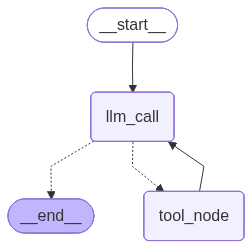

In [ ]:
tools = [get_db_overview, describe_table, execute_sql]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = model.bind_tools(tools)

# Step 2: Define state

from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator


class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int


# Step 3: Define model node
from langchain.messages import SystemMessage


def llm_call(state: dict):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            model_with_tools.invoke(
                [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
            )
        ],
        "llm_calls": state.get("llm_calls", 0) + 1,
    }


# Step 4: Define tool node

from langchain.messages import ToolMessage


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# Step 5: Define logic to determine whether to end

from typing import Literal
from langgraph.graph import StateGraph, START, END


# Conditional edge function to route to the tool node or end based upon whether the LLM made a tool call
MAX_LLM_CALLS = 20


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call."""

    if state.get("llm_calls", 0) >= MAX_LLM_CALLS:
        return END

    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool_node"

    return END


# Step 6: Build agent

# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges("llm_call", should_continue, ["tool_node", END])
agent_builder.add_edge("tool_node", "llm_call")

# Compile the agent
agent = agent_builder.compile()


from IPython.display import Image, display

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage

In [36]:
chat_history = []
user_input = """Database name: california_schools.
User question: In Los Angeles how many schools have more than 500 free meals but less than 700 free or reduced price meals for K-12?"""

chat_history.append(HumanMessage(content=user_input))
result = agent.invoke({"messages": chat_history})
chat_history = result["messages"]

print_messages([chat_history[-1]])

================================== Ai Message ==================================

[Reasoning]
The question asks for schools "In Los Angeles". Based on the data, there are two cities: "Los Angeles" and "West Los Angeles". The user likely means the city of "Los Angeles" specifically, not the broader Los Angeles area. Let me verify if there are any schools in "West Los Angeles" that match the criteria.

From my last query, I can see that only "Los Angeles" has matching schools (75), and "West Los Angeles" has 0 matching schools. So the answer is 75 schools.

Let me double-check by looking at the data more carefully to ensure I'm interpreting the question correctly. The question asks for:
- Location: Los Angeles (city)
- Free meals (K-12) > 500
- Free or reduced price meals (K-12) < 700

My query correctly filters for these conditions. The result is 75 schools.

Based on my exploration of the database, I found that:

1. The `schools` table contains the city information, and there are two c

In [37]:
# SELECT NAME FROM Vendor WHERE BusinessEntityID = 1492

In [68]:
print(execute_sql.func('thrombosis_prediction', "SELECT DISTINCT T1.Diagnosis FROM Patient AS T1 INNER JOIN Laboratory AS T2 ON T1.ID = T2.ID WHERE T2.GPT > 60 ORDER BY T1.Birthday ASC"))

Database: thrombosis_prediction

Diagnosis
---------
Adult STILL
PSS, RA susp
PNc
MRA, SJS
RA, UC
PSS
AORTITIS
PSS, PM
PN

Vasculitis
BEHCET
SLE, SJS
SLE
PM/DM
RA
ITP
MRA
Sweet
RA, SJS, PM
PMPSSRA
SLE, APS
PSS, SJS, PBC
SLE, ITP
SLE susp
MCTD
PN, AGA
DM
Psoriatic Arthritis
SLE, PM
PM
collagen susp
relapsing polychondritis
DM, SJS, RA
SJS
RA,SJS
MCTD, SJS
DM (amyopathic)


In [70]:
print(execute_sql.func('thrombosis_prediction', """SELECT DISTINCT p.Diagnosis
FROM Patient p
JOIN Laboratory l ON p.ID = l.ID
WHERE l.GPT > 60
ORDER BY p.Birthday ASC"""))

Database: thrombosis_prediction

Diagnosis
---------
Adult STILL
PSS, RA susp
PNc
MRA, SJS
RA, UC
PSS
AORTITIS
PSS, PM
PN

Vasculitis
BEHCET
SLE, SJS
SLE
PM/DM
RA
ITP
MRA
Sweet
RA, SJS, PM
PMPSSRA
SLE, APS
PSS, SJS, PBC
SLE, ITP
SLE susp
MCTD
PN, AGA
DM
Psoriatic Arthritis
SLE, PM
PM
collagen susp
relapsing polychondritis
DM, SJS, RA
SJS
RA,SJS
MCTD, SJS
DM (amyopathic)


In [14]:
print(execute_sql.func('california_schools', """SELECT s.School, 
       f.`Enrollment (K-12)` as enrollment,
       sat.AvgScrRead, sat.AvgScrMath, sat.AvgScrWrite,
       (sat.AvgScrRead + sat.AvgScrMath + sat.AvgScrWrite) as total_sat
FROM schools s
JOIN frpm f ON s.CDSCode = f.CDSCode
JOIN satscores sat ON s.CDSCode = sat.cds
WHERE s.EILCode = 'HS'
ORDER BY f.`Enrollment (K-12)` DESC
LIMIT 1"""))

Database: california_schools

School | enrollment | AvgScrRead | AvgScrMath | AvgScrWrite | total_sat
------ | ---------- | ---------- | ---------- | ----------- | ---------
Paramount High | 4814.0 | 424 | 434 | 414 | 1272


In [40]:
print_messages(chat_history)

================================ Human Message =================================

Database name: california_schools.
User question: In Los Angeles how many schools have more than 500 free meals but less than 700 free or reduced price meals for K-12?

================================== Ai Message ==================================

[Reasoning]
I need to explore the california_schools database to understand its structure and find the relevant tables and columns to answer this question.

The question asks about:
- Schools in Los Angeles
- More than 500 free meals
- Less than 700 free or reduced price meals for K-12

Let me start by getting the database overview.


Tool Calls:
  get_db_overview (call_3324cb4a82d1433b99cc64e5)
  Args:
    db_name: california_schools

================================= Tool Message =================================

Database: california_schools

SQLite tables:
  - frpm
  - satscores
  - schools

Documentation:
# Documentation

- Eligible free rate for K-12 = 

In [41]:
import random
import re
import time
import sqlite3 as _sqlite3
from pathlib import Path
from typing import Any, Optional

import pandas as pd


# ---------------------------------------------------------------------------
# Monkey-patch ChatOpenRouter._generate to expose token usage
# ---------------------------------------------------------------------------
_orig_generate = ChatOpenRouter._generate


def _patched_generate(
    self,
    messages: list[BaseMessage],
    stop: Optional[list[str]] = None,
    run_manager: Any = None,
    **kwargs: Any,
) -> ChatResult:
    payload: dict[str, Any] = {
        "model": self.model,
        "messages": self._format_messages(messages),
        "include_reasoning": self.include_reasoning,
        **self.extra_params,
    }
    if stop:
        payload["stop"] = stop
    if self.temperature is not None:
        payload["temperature"] = self.temperature
    if self.max_tokens is not None:
        payload["max_tokens"] = self.max_tokens
    if "tools" in kwargs:
        payload["tools"] = kwargs["tools"]

    resp = requests.post(
        self.base_url,
        headers={
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type": "application/json",
        },
        json=payload,
        timeout=300,
    )
    resp.raise_for_status()
    data = resp.json()

    choice = data["choices"][0]
    raw_msg = choice["message"]

    additional_kwargs: dict[str, Any] = {}
    if raw_msg.get("reasoning"):
        additional_kwargs["reasoning"] = raw_msg["reasoning"]

    tool_calls = []
    if raw_msg.get("tool_calls"):
        for tc in raw_msg["tool_calls"]:
            args = tc["function"]["arguments"]
            tool_calls.append(
                {
                    "id": tc["id"],
                    "name": tc["function"]["name"],
                    "args": json.loads(args) if isinstance(args, str) else args,
                }
            )

    usage = data.get("usage", {})
    response_metadata = {
        "prompt_tokens": usage.get("prompt_tokens", 0),
        "completion_tokens": usage.get("completion_tokens", 0),
        "total_tokens": usage.get("total_tokens", 0),
    }

    ai_msg = AIMessage(
        content=raw_msg.get("content") or "",
        additional_kwargs=additional_kwargs,
        tool_calls=tool_calls,
        response_metadata=response_metadata,
    )
    return ChatResult(generations=[ChatGeneration(message=ai_msg)])


ChatOpenRouter._generate = _patched_generate
print("ChatOpenRouter._generate patched -- token usage is now tracked in response_metadata")


# ---------------------------------------------------------------------------
# Helper functions for validation
# ---------------------------------------------------------------------------

_SQL_BLOCK_RE = re.compile(r"```sql\s*\n?(.*?)\n?\s*```", re.DOTALL | re.IGNORECASE)
_FINAL_SQL_RE = re.compile(r"Final SQL:\s*\n?(SELECT\b.*)", re.DOTALL | re.IGNORECASE)


def parse_sql_from_response(messages: list[BaseMessage]) -> str:
    """Extract the last SQL query from the agent message chain."""
    for msg in reversed(messages):
        if not isinstance(msg, AIMessage) or not msg.content:
            continue
        m = _SQL_BLOCK_RE.search(msg.content)
        if m:
            return m.group(1).strip()
        m = _FINAL_SQL_RE.search(msg.content)
        if m:
            return m.group(1).strip()
    return ""


def execute_sql_raw(db_name: str, sql_query: str) -> tuple[list[str], list[tuple]] | None:
    """Execute SQL and return (column_names, rows), or None on error."""
    if not sql_query:
        return None
    sqlite_file = os.path.join(DEV_DB_PATH, db_name, f"{db_name}.sqlite")
    try:
        conn = _sqlite3.connect(sqlite_file)
        cursor = conn.execute(sql_query)
        if cursor.description is None:
            conn.close()
            return ([], [])
        col_names = [desc[0] for desc in cursor.description]
        rows = cursor.fetchall()
        conn.close()
        return (col_names, rows)
    except Exception:
        return None


def format_exec_result(raw: tuple[list[str], list[tuple]] | None, max_rows: int = 50) -> str:
    """Serialize execution result into a human-readable string for the xlsx."""
    if raw is None:
        return "ERROR"
    col_names, rows = raw
    if not rows:
        return "(empty result)"
    lines = [" | ".join(col_names)]
    for row in rows[:max_rows]:
        lines.append(" | ".join(str(v) for v in row))
    if len(rows) > max_rows:
        lines.append(f"... ({len(rows)} total rows)")
    return "\n".join(lines)


def compute_ex(db_name: str, sql_pred: str, sql_true: str) -> int:
    """For every column in the true result, check that a column with identical
    values (same order) exists in the pred result.  Pred may have extra columns;
    column aliases are ignored -- only cell values matter."""
    raw_true = execute_sql_raw(db_name, sql_true)
    raw_pred = execute_sql_raw(db_name, sql_pred)
    if raw_true is None or raw_pred is None:
        return 0

    _, rows_true = raw_true
    _, rows_pred = raw_pred

    if not rows_true:
        return 1 if not rows_pred else 0

    n_true_cols = len(rows_true[0])
    n_pred_cols = len(rows_pred[0]) if rows_pred else 0

    true_columns = [
        tuple(str(row[ci]) for row in rows_true) for ci in range(n_true_cols)
    ]
    pred_columns = [
        tuple(str(row[ci]) for row in rows_pred) for ci in range(n_pred_cols)
    ]

    return 1 if all(tc in pred_columns for tc in true_columns) else 0


def count_tool_calls(messages: list[BaseMessage]) -> int:
    total = 0
    for msg in messages:
        if isinstance(msg, AIMessage) and msg.tool_calls:
            total += len(msg.tool_calls)
    return total


def sum_token_usage(messages: list[BaseMessage]) -> tuple[int, int]:
    """Return (input_tokens, output_tokens) summed over all AI messages."""
    inp, out = 0, 0
    for msg in messages:
        if isinstance(msg, AIMessage):
            meta = getattr(msg, "response_metadata", None) or {}
            inp += meta.get("prompt_tokens", 0)
            out += meta.get("completion_tokens", 0)
    return inp, out


print("Helper functions defined.")

ChatOpenRouter._generate patched -- token usage is now tracked in response_metadata
Helper functions defined.


In [ ]:
# ---------------------------------------------------------------------------
# Validation: run the agent on 100 random dev questions
# ---------------------------------------------------------------------------

DEV_JSON_PATH = Path(
    "/Users/kulyaskin_mikhail/ITMO/Agents/Text2SQL/data/dev_20240627/dev.json"
)
OUTPUT_XLSX = Path(
    "/Users/kulyaskin_mikhail/ITMO/Agents/Text2SQL/notebooks/validation_results.xlsx"
)

with open(DEV_JSON_PATH, "r", encoding="utf-8") as fh:
    dev_data = json.load(fh)

SAMPLE_SIZE = 50
random.seed(42)
sample = random.sample(dev_data, min(SAMPLE_SIZE, len(dev_data)))
print(f"Sampled {len(sample)} questions from {len(dev_data)} total")

rows: list[dict] = []

for idx, item in enumerate(sample):
    qid = item["question_id"]
    db_id = item["db_id"]
    question = item["question"]
    sql_true = item["SQL"]
    difficulty = item["difficulty"]

    prompt = f"Database: {db_id}. User question: {question}"
    print(f"[{idx + 1}/{len(sample)}] qid={qid}  db={db_id}  difficulty={difficulty}")

    t0 = time.time()
    try:
        result = agent.invoke({"messages": [HumanMessage(content=prompt)]})
        elapsed = time.time() - t0
        msgs = result["messages"]

        sql_pred = parse_sql_from_response(msgs)
        n_tools = count_tool_calls(msgs)
        tok_in, tok_out = sum_token_usage(msgs)
        ex = compute_ex(db_id, sql_pred, sql_true)

        raw_true = execute_sql_raw(db_id, sql_true)
        raw_pred = execute_sql_raw(db_id, sql_pred)

        rows.append(
            {
                "question_id": qid,
                "db_id": db_id,
                "question": question,
                "difficulty": difficulty,
                "sql_true": sql_true,
                "sql_pred": sql_pred,
                "exec_result_true": format_exec_result(raw_true),
                "exec_result_pred": format_exec_result(raw_pred),
                "EX": ex,
                "time_s": round(elapsed, 2),
                "input_tokens": tok_in,
                "output_tokens": tok_out,
                "num_tool_calls": n_tools,
            }
        )
        print(
            f"  -> EX={ex}  time={elapsed:.1f}s  "
            f"tokens_in={tok_in}  tokens_out={tok_out}  tool_calls={n_tools}"
        )

    except Exception as exc:
        elapsed = time.time() - t0
        print(f"  -> ERROR ({elapsed:.1f}s): {exc}")
        rows.append(
            {
                "question_id": qid,
                "db_id": db_id,
                "question": question,
                "difficulty": difficulty,
                "sql_true": sql_true,
                "sql_pred": "",
                "exec_result_true": format_exec_result(execute_sql_raw(db_id, sql_true)),
                "exec_result_pred": f"ERROR: {exc}",
                "EX": 0,
                "time_s": round(elapsed, 2),
                "input_tokens": 0,
                "output_tokens": 0,
                "num_tool_calls": 0,
            }
        )

# ---------------------------------------------------------------------------
# Aggregate and save
# ---------------------------------------------------------------------------
df = pd.DataFrame(rows)

overall_ex = df["EX"].mean()
avg_time = df["time_s"].mean()
avg_tok_in = df["input_tokens"].mean()
avg_tok_out = df["output_tokens"].mean()
avg_tools = df["num_tool_calls"].mean()

print(f"\n{'=' * 60}")
print(f"Overall EX accuracy : {overall_ex:.4f}  ({df['EX'].sum()}/{len(df)})")
print(f"Avg time            : {avg_time:.1f} s")
print(f"Avg input tokens    : {avg_tok_in:.0f}")
print(f"Avg output tokens   : {avg_tok_out:.0f}")
print(f"Avg tool calls      : {avg_tools:.1f}")

diff_stats = df.groupby("difficulty")["EX"].agg(["mean", "sum", "count"])
print("\nEX by difficulty:")
for diff, row in diff_stats.iterrows():
    print(f"  {diff:>20s}: {row['mean']:.4f}  ({int(row['sum'])}/{int(row['count'])})")

# Write results to CSV
OUTPUT_CSV = '/Users/kulyaskin_mikhail/ITMO/Agents/Text2SQL/notebooks/validation_results.csv'
df.to_csv(OUTPUT_CSV, index=False)

print(f"\nResults saved to {OUTPUT_CSV}")

Sampled 50 questions from 1534 total
[1/50] qid=1309  db=thrombosis_prediction  difficulty=moderate
  -> EX=1  time=81.4s  tokens_in=65391  tokens_out=1658  tool_calls=7
[2/50] qid=228  db=toxicology  difficulty=moderate
  -> EX=1  time=55.3s  tokens_in=54454  tokens_out=1864  tool_calls=8
[3/50] qid=51  db=california_schools  difficulty=simple
  -> EX=0  time=53.2s  tokens_in=76215  tokens_out=1599  tool_calls=11
[4/50] qid=1518  db=debit_card_specializing  difficulty=simple
  -> EX=1  time=35.7s  tokens_in=24022  tokens_out=1328  tool_calls=6
[5/50] qid=563  db=codebase_community  difficulty=moderate
  -> EX=1  time=24.8s  tokens_in=33434  tokens_out=1008  tool_calls=5
[6/50] qid=501  db=card_games  difficulty=moderate
  -> EX=1  time=39.4s  tokens_in=91516  tokens_out=1303  tool_calls=9
[7/50] qid=457  db=card_games  difficulty=simple
  -> EX=0  time=93.2s  tokens_in=119028  tokens_out=2066  tool_calls=10
[8/50] qid=285  db=toxicology  difficulty=challenging
  -> EX=1  time=117.0s  

IllegalCharacterError: Diagnosis
Adult STILL
PSS, RA susp
PNc
MRA, SJS
RA, UC
PSS
AORTITIS
PSS, PM
PN

Vasculitis
BEHCET
SLE, SJS
SLE
PM/DM
RA
ITP
MRA
Sweet
RA, SJS, PM
PMPSSRA
SLE, APS
PSS, SJS, PBC
SLE, ITP
SLE susp
MCTD
PN, AGA
DM
Psoriatic Arthritis
SLE, PM
PM
collagen susp
relapsing polychondritis
DM, SJS, RA
SJS
RA,SJS
MCTD, SJS
DM (amyopathic) cannot be used in worksheets.

In [49]:
df.head()

,question_id,db_id,question,difficulty,sql_true,sql_pred,exec_result_true,exec_result_pred,EX,time_s,input_tokens,output_tokens,num_tool_calls
0,1309,thrombosis_prediction,Please list a patient's platelet level if it i...,moderate,SELECT T2.PLT FROM Patient AS T1 INNER JOIN La...,"SELECT p.ID, l.PLT\nFROM Patient p\nJOIN Labor...",PLT\n219\n222\n326\n286\n236\n278\n232\n272\n2...,ID | PLT\n81043 | 219\n81043 | 222\n81043 | 32...,1,81.39,65391,1658,7
1,228,toxicology,How much of the hydrogen in molecule TR206 is ...,moderate,SELECT ROUND(CAST(COUNT(CASE WHEN T.element = ...,"SELECT printf('%.4f', CAST(SUM(CASE WHEN eleme...",ROUND(CAST(COUNT(CASE WHEN T.element = 'h' THE...,hydrogen_percentage\n45.4545,1,55.34,54454,1864,8
2,51,california_schools,In which mailing street address can you find t...,simple,"SELECT T2.MailStreet, T2.School FROM satscores...","SELECT schools.MailStreet, schools.School\nFRO...",MailStreet | School\n1050 York Street | S.F. I...,(empty result),0,53.22,76215,1599,11
3,1518,debit_card_specializing,"For the deal happened at 2012/8/24 12:42:00, w...",simple,SELECT T2.Country FROM transactions_1k AS T1 I...,SELECT G.Country \nFROM transactions_1k T1 \nJ...,Country\nCZE\nCZE,Country\nCZE\nCZE,1,35.67,24022,1328,6
4,563,codebase_community,User No.3025 gave a comment at 20:29:39 on 201...,moderate,SELECT T1.FavoriteCount FROM posts AS T1 INNER...,SELECT p.FavoriteCount\nFROM comments c\nJOIN ...,FavoriteCount\n3,FavoriteCount\n3,1,24.79,33434,1008,5


In [54]:
# Write results to CSV
OUTPUT_CSV = '/Users/kulyaskin_mikhail/ITMO/Agents/Text2SQL/notebooks/validation_results.csv'
df.to_csv(OUTPUT_CSV, index=False)

print(f"\nResults saved to {OUTPUT_CSV}")


Results saved to /Users/kulyaskin_mikhail/ITMO/Agents/Text2SQL/notebooks/validation_results.csv


In [ ]:
# 50 Вопросов, 40 минут, 1.5 бакса

In [ ]:
# Overall EX accuracy : 0.5800  (29/50)
# Avg time            : 44.9 s
# Avg input tokens    : 50225
# Avg output tokens   : 1342
# Avg tool calls      : 7.3

# EX by difficulty:
#            challenging: 0.4000  (2/5)
#               moderate: 0.6364  (7/11)
#                 simple: 0.5882  (20/34)